# Bike Demand Forecasting — EDA
Exploratory data analysis on `dataset/train_set.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

TRAIN_CSV = Path("dataset/train_set.csv")
CITY_COLORS = {"city 1": "#2196F3", "city 2": "#FF5722", "city 3": "#4CAF50"}

df = pd.read_csv(TRAIN_CSV, low_memory=False)
df["started_at"] = pd.to_datetime(df["started_at"])
df["hour"]       = pd.to_datetime(df["hour_ts"]).dt.hour
cities           = sorted(df["city"].unique())

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")
print(f"Cities: {cities}")

Loaded 1,605,208 rows, 35 columns
Cities: ['city 1', 'city 2', 'city 3']


## 1. City Overview

city 1:
  Rows     : 1,142,317  (71.2%)
  Stations : 807
  Dates    : 2025-01-01 → 2025-02-28  (58 days)



city 2:
  Rows     : 460,642  (28.7%)
  Stations : 783
  Dates    : 2025-01-01 → 2025-02-28  (58 days)

city 3:
  Rows     : 2,249  (0.1%)
  Stations : 211
  Dates    : 2025-01-08 → 2025-01-12  (4 days)



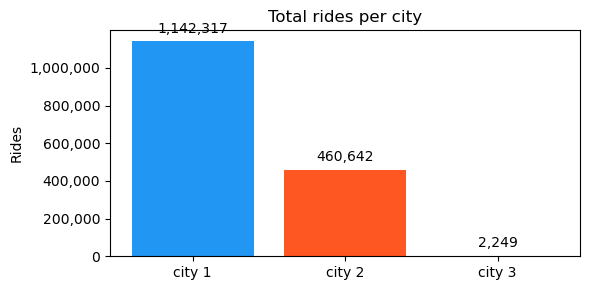

In [2]:
for city in cities:
    g = df[df["city"] == city]
    print(f"{city}:")
    print(f"  Rows     : {len(g):,}  ({len(g)/len(df):.1%})")
    print(f"  Stations : {g['start_station_id'].nunique()}")
    print(f"  Dates    : {g['started_at'].min().date()} → {g['started_at'].max().date()}  "
          f"({(g['started_at'].max()-g['started_at'].min()).days} days)")
    print()

fig, ax = plt.subplots(figsize=(6, 3))
counts = df["city"].value_counts()[cities]
bars = ax.bar(cities, counts.values, color=[CITY_COLORS[c] for c in cities])
ax.bar_label(bars, labels=[f"{v:,}" for v in counts.values], padding=4)
ax.set_title("Total rides per city")
ax.set_ylabel("Rides")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 2. Missing Values

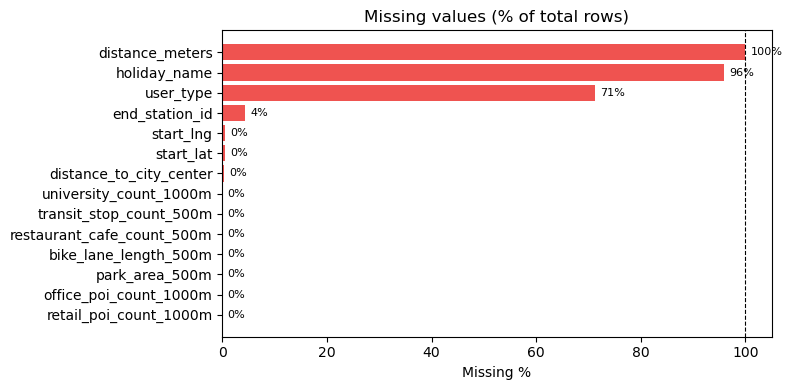


Missing by city:



  city 1:
    distance_meters                          100.0%
    user_type                                100.0%
    holiday_name                             95.7%
    start_lat                                0.5%
    start_lng                                0.5%
    distance_to_city_center                  0.5%



  city 2:
    distance_meters                          100.0%
    holiday_name                             96.3%
    end_station_id                           15.0%
    bike_lane_length_500m                    0.0%
    park_area_500m                           0.0%
    university_count_1000m                   0.0%
    office_poi_count_1000m                   0.0%
    retail_poi_count_1000m                   0.0%
    restaurant_cafe_count_500m               0.0%
    transit_stop_count_500m                  0.0%
    distance_to_city_center                  0.0%

  city 3:
    distance_meters                          100.0%
    start_lat                                100.0%
    start_lng                                100.0%
    holiday_name                             100.0%


In [3]:
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(missing_pct.index[::-1], missing_pct.values[::-1], color="#EF5350")
ax.set_xlabel("Missing %")
ax.set_title("Missing values (% of total rows)")
ax.axvline(100, color="black", linewidth=0.8, linestyle="--")
for i, (col, pct) in enumerate(zip(missing_pct.index[::-1], missing_pct.values[::-1])):
    ax.text(pct + 1, i, f"{pct:.0f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print("\nMissing by city:")
for city in cities:
    g = df[df["city"] == city]
    city_miss = {c: g[c].isnull().mean()*100 for c in df.columns if g[c].isnull().sum() > 0}
    print(f"\n  {city}:")
    for col, pct in sorted(city_miss.items(), key=lambda x: -x[1]):
        print(f"    {col:<40} {pct:.1f}%")

## 3. Constant / Useless Columns per City

In [4]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for city in cities:
    g = df[df["city"] == city]
    constants = [c for c in num_cols if g[c].nunique() <= 1]
    print(f"{city}: {constants}")

city 1: ['distance_meters', 'bike_lane_length_500m', 'park_area_500m', 'university_count_1000m', 'office_poi_count_1000m', 'retail_poi_count_1000m', 'restaurant_cafe_count_500m', 'transit_stop_count_500m', 'distance_to_nearest_rail_station']


city 2: ['distance_meters']
city 3: ['distance_meters', 'start_lat', 'start_lng', 'precipitation', 'rain', 'snowfall', 'holiday']


## 4. Demand Distribution (station-hour level)

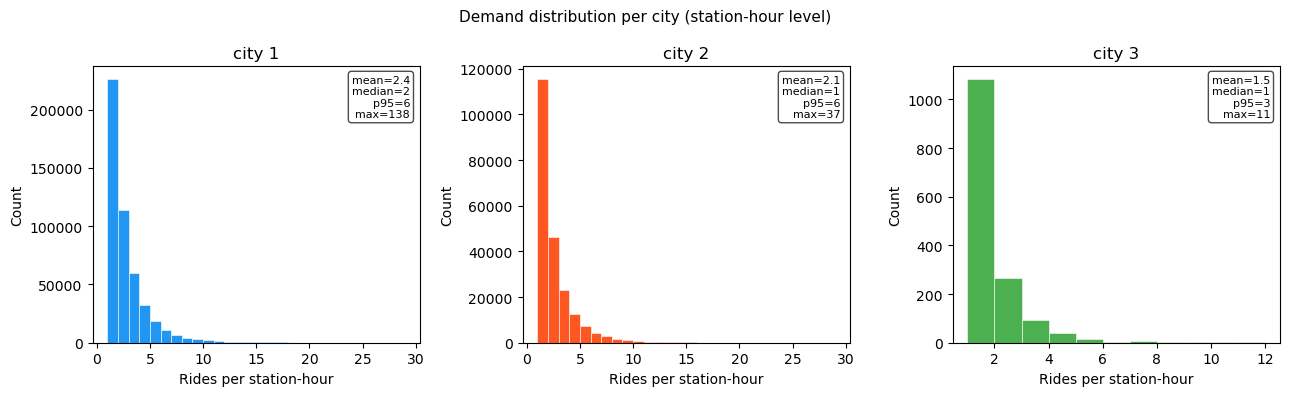

In [5]:
demand = df.groupby(["city", "start_station_id", "hour_ts"]).size().reset_index(name="demand")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, city in zip(axes, cities):
    g = demand[demand["city"] == city]["demand"]
    ax.hist(g, bins=range(1, min(g.max()+2, 30)), color=CITY_COLORS[city], edgecolor="white", linewidth=0.4)
    ax.set_title(city)
    ax.set_xlabel("Rides per station-hour")
    ax.set_ylabel("Count")
    stats = f"mean={g.mean():.1f}\nmedian={g.median():.0f}\np95={g.quantile(0.95):.0f}\nmax={g.max()}"
    ax.text(0.97, 0.97, stats, transform=ax.transAxes, va="top", ha="right",
            fontsize=8, bbox=dict(boxstyle="round", fc="white", alpha=0.7))
fig.suptitle("Demand distribution per city (station-hour level)", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Hourly Demand Pattern

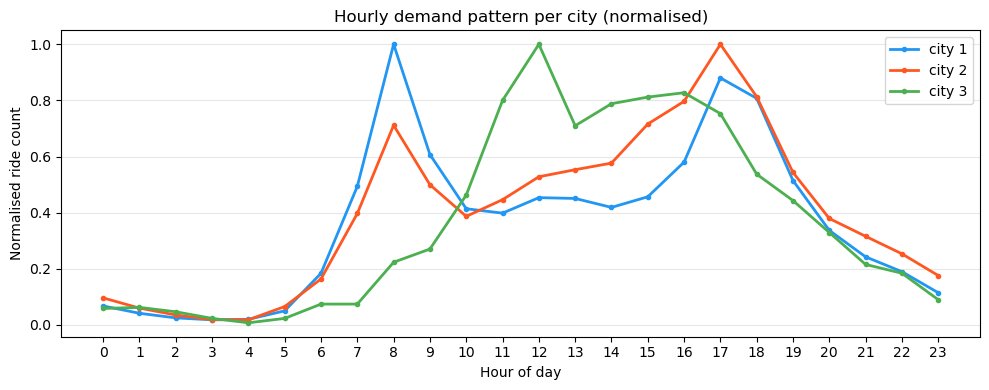

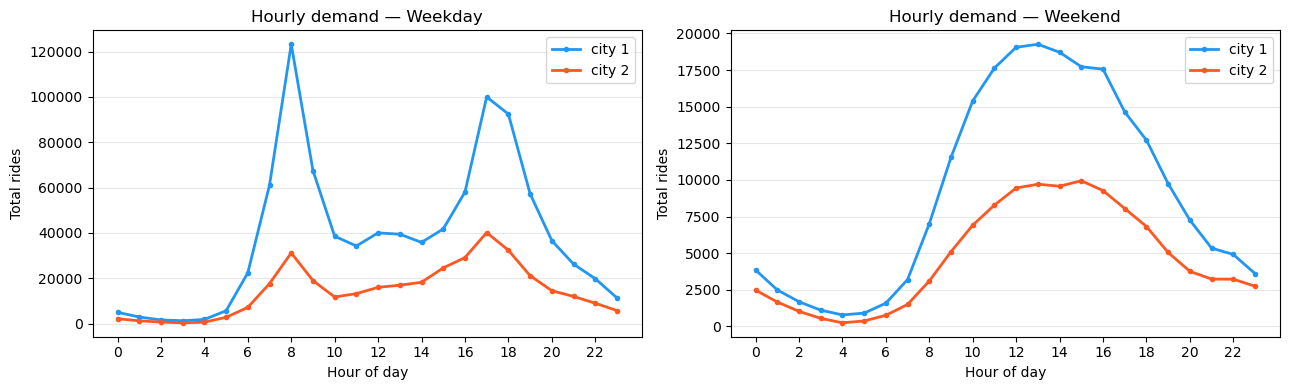

In [6]:
# Normalised hourly pattern across all cities
fig, ax = plt.subplots(figsize=(10, 4))
for city in cities:
    g = df[df["city"] == city]
    hourly = g.groupby("hour").size()
    hourly = hourly / hourly.max()
    ax.plot(hourly.index, hourly.values, marker="o", markersize=3,
            label=city, color=CITY_COLORS[city], linewidth=2)
ax.set_xlabel("Hour of day"); ax.set_ylabel("Normalised ride count")
ax.set_title("Hourly demand pattern per city (normalised)")
ax.set_xticks(range(24)); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Weekday vs weekend for city 1 and 2
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, label, mask_val in zip(axes, ["Weekday", "Weekend"], [0, 1]):
    for city in ["city 1", "city 2"]:
        g = df[(df["city"] == city) & (df["weekend"] == mask_val)]
        hourly = g.groupby("hour").size()
        ax.plot(hourly.index, hourly.values, marker="o", markersize=3,
                label=city, color=CITY_COLORS[city], linewidth=2)
    ax.set_title(f"Hourly demand — {label}")
    ax.set_xlabel("Hour of day"); ax.set_ylabel("Total rides")
    ax.set_xticks(range(0, 24, 2)); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Rides by Day of Week & Weekday vs Weekend

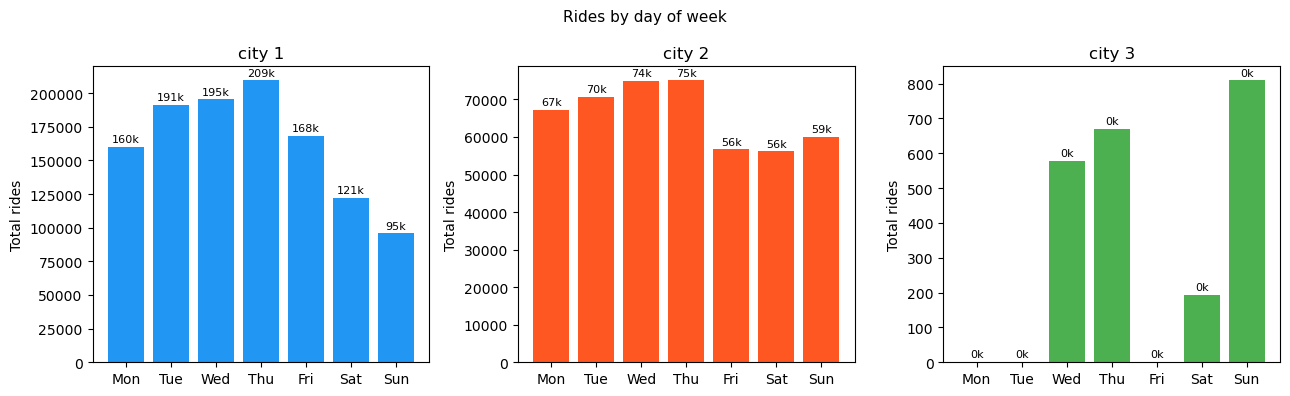

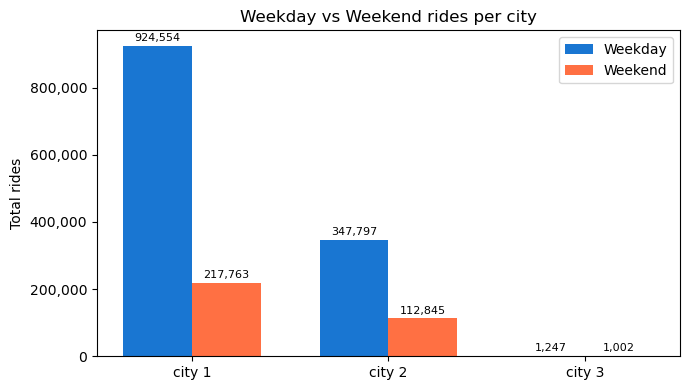

In [7]:
day_labels = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, city in zip(axes, cities):
    g = df[df["city"] == city]
    by_day = g.groupby("weekday").size().reindex(range(7), fill_value=0)
    bars = ax.bar(day_labels, by_day.values, color=CITY_COLORS[city])
    ax.bar_label(bars, labels=[f"{v//1000}k" for v in by_day.values], padding=2, fontsize=8)
    ax.set_title(city); ax.set_ylabel("Total rides")
fig.suptitle("Rides by day of week", fontsize=11)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(cities))
wd = [df[(df["city"]==c) & (df["weekend"]==0)].shape[0] for c in cities]
we = [df[(df["city"]==c) & (df["weekend"]==1)].shape[0] for c in cities]
w = 0.35
b1 = ax.bar(x - w/2, wd, w, label="Weekday", color="#1976D2")
b2 = ax.bar(x + w/2, we, w, label="Weekend", color="#FF7043")
ax.bar_label(b1, labels=[f"{v:,}" for v in wd], padding=2, fontsize=8)
ax.bar_label(b2, labels=[f"{v:,}" for v in we], padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(cities)
ax.set_ylabel("Total rides"); ax.set_title("Weekday vs Weekend rides per city"); ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout(); plt.show()

## 7. Demand Heatmap: Hour × Weekday

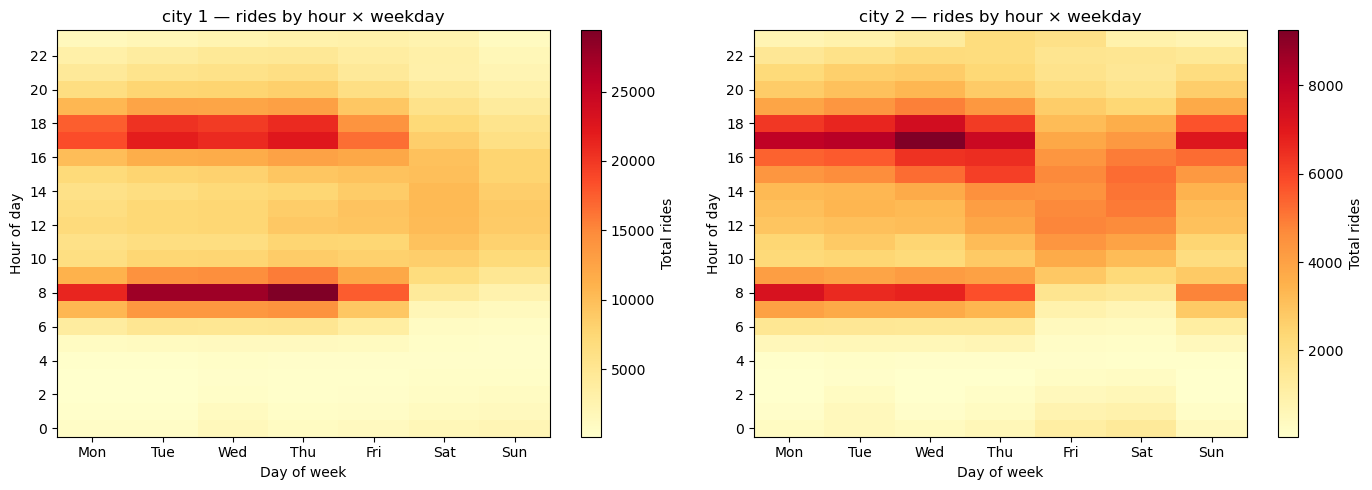

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, city in zip(axes, ["city 1", "city 2"]):
    g = df[df["city"] == city]
    pivot = g.groupby(["hour", "weekday"]).size().unstack(fill_value=0)
    pivot.columns = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", origin="lower")
    ax.set_xticks(range(7)); ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(0, 24, 2)); ax.set_yticklabels(range(0, 24, 2))
    ax.set_xlabel("Day of week"); ax.set_ylabel("Hour of day")
    ax.set_title(f"{city} — rides by hour × weekday")
    fig.colorbar(im, ax=ax, label="Total rides")
plt.tight_layout(); plt.show()

## 8. Daily Demand Over Time

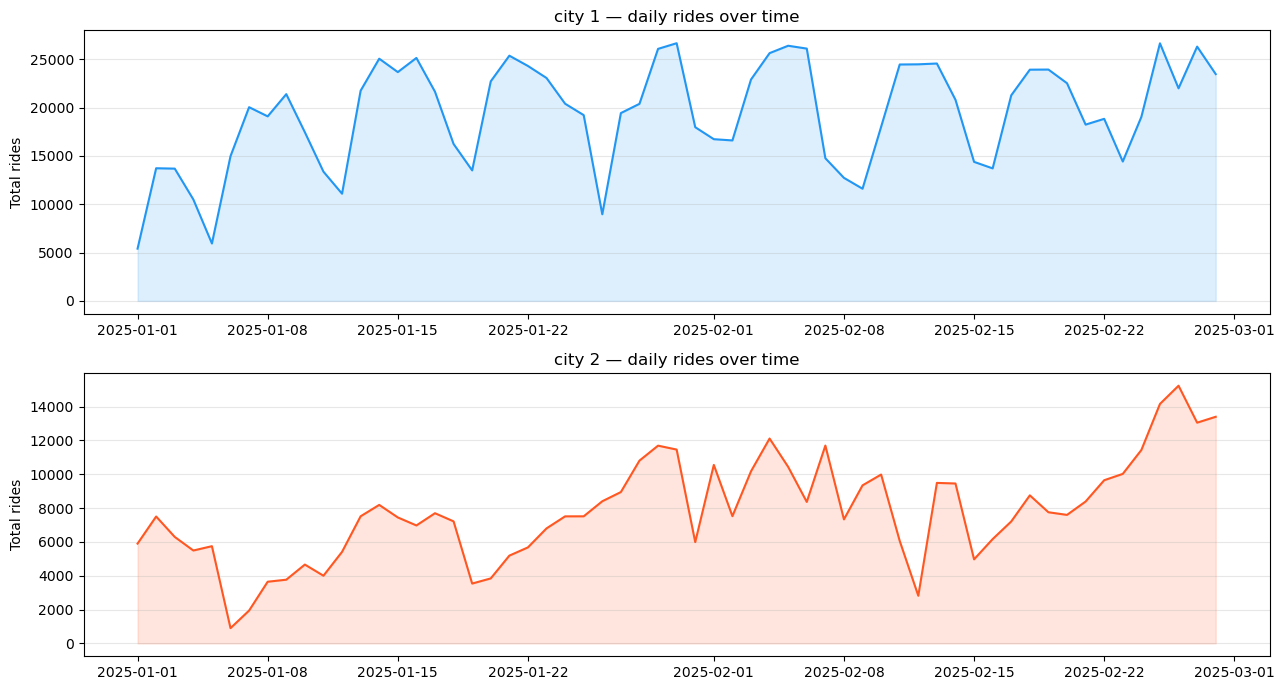

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7))
for ax, city in zip(axes, ["city 1", "city 2"]):
    g = df[df["city"] == city].copy()
    g["date_dt"] = pd.to_datetime(g["date"])
    daily = g.groupby("date_dt").size()
    ax.plot(daily.index, daily.values, color=CITY_COLORS[city], linewidth=1.5)
    ax.fill_between(daily.index, daily.values, alpha=0.15, color=CITY_COLORS[city])
    ax.set_title(f"{city} — daily rides over time")
    ax.set_ylabel("Total rides"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Weather Distributions

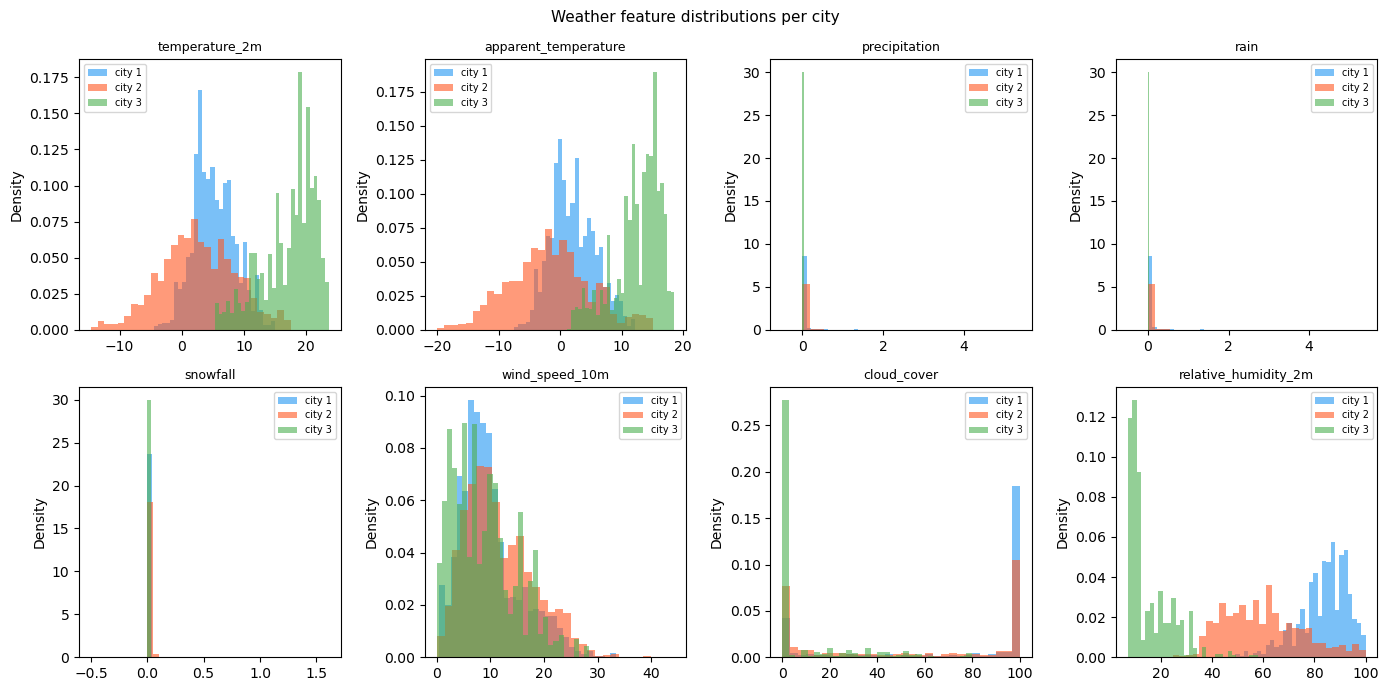

In [10]:
weather_cols = ["temperature_2m","apparent_temperature","precipitation",
                "rain","snowfall","wind_speed_10m","cloud_cover","relative_humidity_2m"]
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, col in zip(axes.flat, weather_cols):
    for city in cities:
        g = df[df["city"] == city][col].dropna()
        ax.hist(g, bins=30, alpha=0.6, label=city, color=CITY_COLORS[city], density=True, edgecolor="none")
    ax.set_title(col, fontsize=9); ax.legend(fontsize=7); ax.set_ylabel("Density")
fig.suptitle("Weather feature distributions per city", fontsize=11)
plt.tight_layout(); plt.show()

## 10. Demand vs Weather

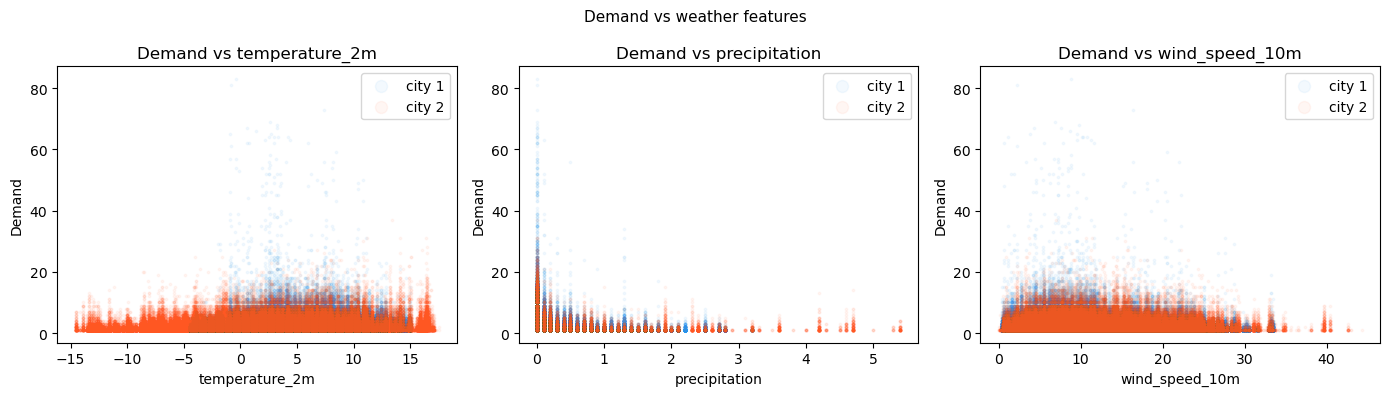

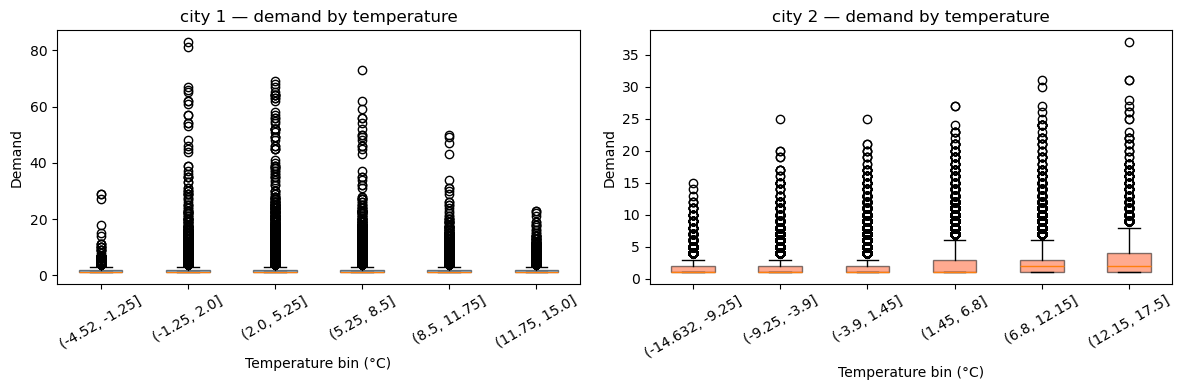

In [11]:
demand_hr = df.groupby(["city","start_station_id","hour_ts",
                        "temperature_2m","precipitation","wind_speed_10m"]).size().reset_index(name="demand")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, ["temperature_2m","precipitation","wind_speed_10m"]):
    for city in ["city 1","city 2"]:
        g = demand_hr[demand_hr["city"]==city]
        ax.scatter(g[feat], g["demand"], alpha=0.05, s=3, color=CITY_COLORS[city], label=city)
    ax.set_xlabel(feat); ax.set_ylabel("Demand"); ax.set_title(f"Demand vs {feat}"); ax.legend(markerscale=5)
fig.suptitle("Demand vs weather features", fontsize=11)
plt.tight_layout(); plt.show()

# Demand by temperature bin
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, city in zip(axes, ["city 1","city 2"]):
    g = demand_hr[demand_hr["city"]==city].copy()
    g["temp_bin"] = pd.cut(g["temperature_2m"], bins=6)
    box_data = [grp["demand"].values for _, grp in g.groupby("temp_bin", observed=True)]
    labels   = [str(b) for b in g.groupby("temp_bin", observed=True).groups.keys()]
    ax.boxplot(box_data, labels=labels, patch_artist=True,
               boxprops=dict(facecolor=CITY_COLORS[city], alpha=0.5))
    ax.set_xlabel("Temperature bin (°C)"); ax.set_ylabel("Demand")
    ax.set_title(f"{city} — demand by temperature"); ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

## 11. Correlation Heatmap

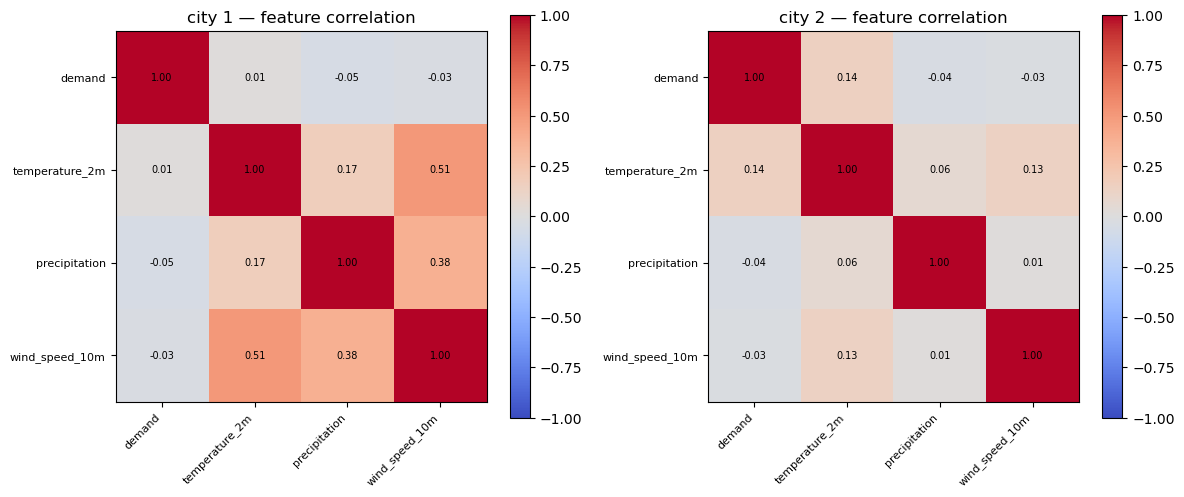

In [12]:
corr_cols = ["demand","temperature_2m","apparent_temperature","precipitation",
             "rain","snowfall","wind_speed_10m","cloud_cover","relative_humidity_2m"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, city in zip(axes, ["city 1","city 2"]):
    g = demand_hr[demand_hr["city"]==city][[c for c in corr_cols if c in demand_hr.columns]].dropna()
    corr = g.corr()
    im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns, fontsize=8)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
    ax.set_title(f"{city} — feature correlation"); fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 12. Station Metadata, User Types & Top Stations

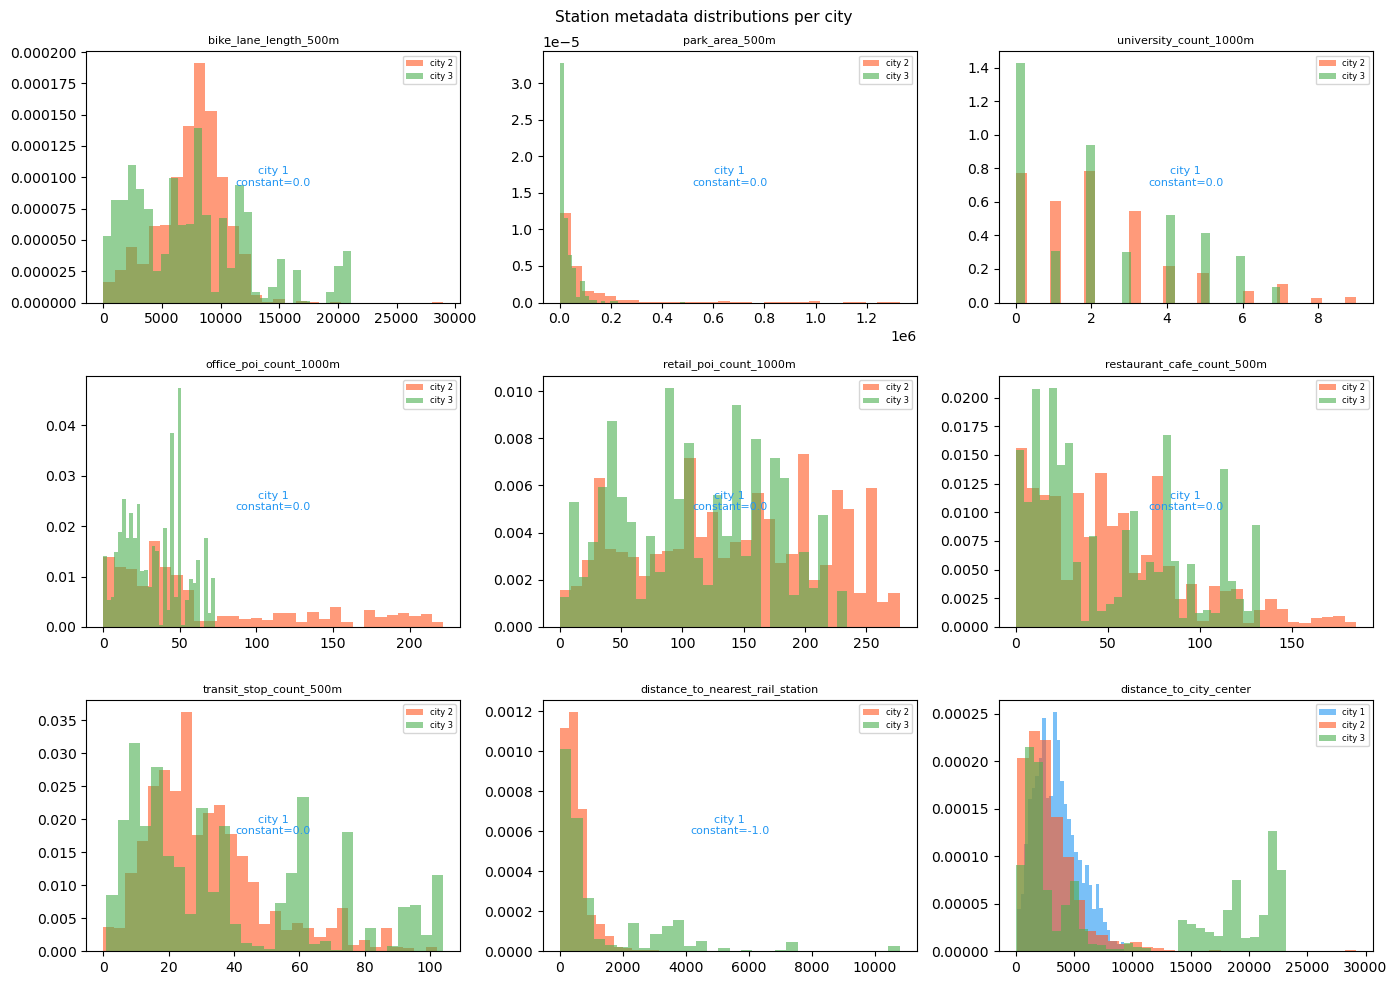

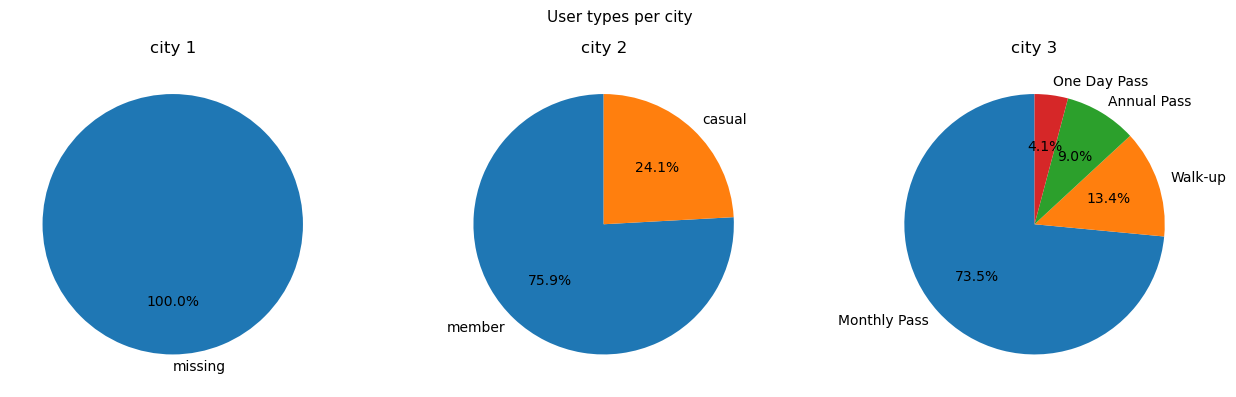

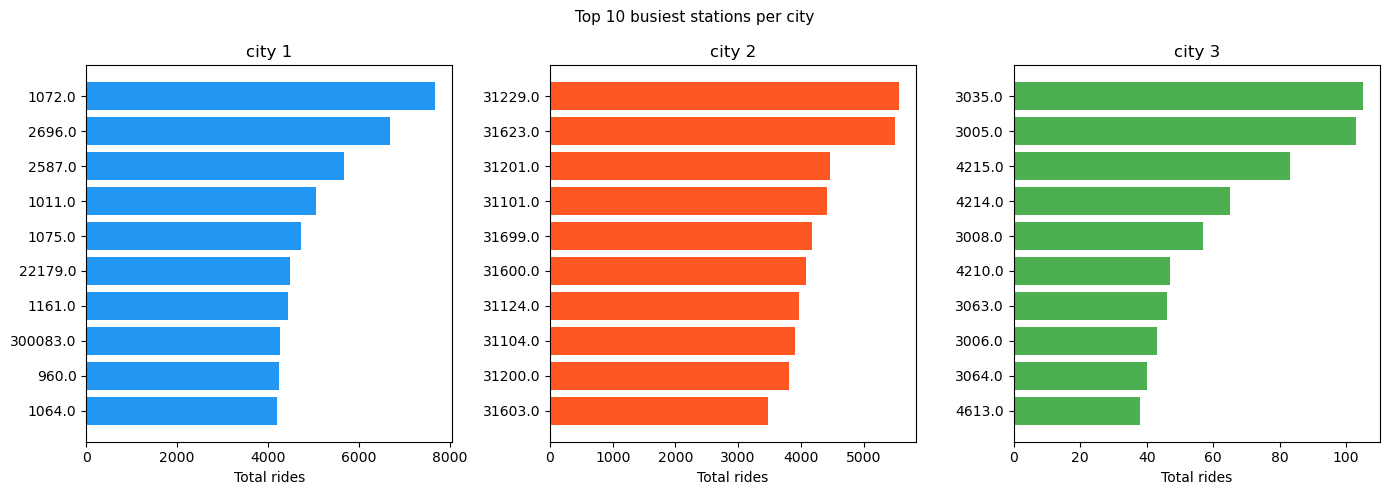

In [13]:
meta_cols = ["bike_lane_length_500m","park_area_500m","university_count_1000m",
             "office_poi_count_1000m","retail_poi_count_1000m","restaurant_cafe_count_500m",
             "transit_stop_count_500m","distance_to_nearest_rail_station","distance_to_city_center"]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, meta_cols):
    for city in cities:
        g = df[df["city"]==city][col].dropna()
        if g.nunique() <= 1:
            ax.text(0.5, 0.5, f"{city}\nconstant={g.unique()[0] if len(g)>0 else 'NaN'}",
                    ha="center", va="center", transform=ax.transAxes, fontsize=8, color=CITY_COLORS[city])
        else:
            ax.hist(g, bins=30, alpha=0.6, label=city, color=CITY_COLORS[city], density=True, edgecolor="none")
    ax.set_title(col, fontsize=8); ax.legend(fontsize=6)
fig.suptitle("Station metadata distributions per city", fontsize=11)
plt.tight_layout(); plt.show()

# User types
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, city in zip(axes, cities):
    g = df[df["city"]==city]
    counts = g["user_type"].value_counts(dropna=False)
    labels = [str(l) if str(l) != "nan" else "missing" for l in counts.index]
    ax.pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=90)
    ax.set_title(city)
fig.suptitle("User types per city", fontsize=11)
plt.tight_layout(); plt.show()

# Top 10 stations
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, city in zip(axes, cities):
    top = df[df["city"]==city].groupby("start_station_id").size().nlargest(10)
    ax.barh([str(s) for s in top.index[::-1]], top.values[::-1], color=CITY_COLORS[city])
    ax.set_title(city); ax.set_xlabel("Total rides")
fig.suptitle("Top 10 busiest stations per city", fontsize=11)
plt.tight_layout(); plt.show()

## 13. Station Variability, Autocorrelation & Outliers

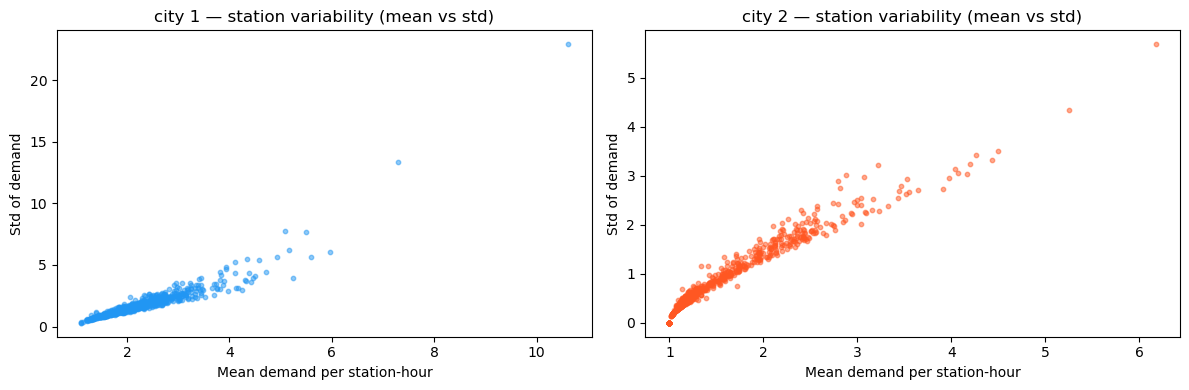

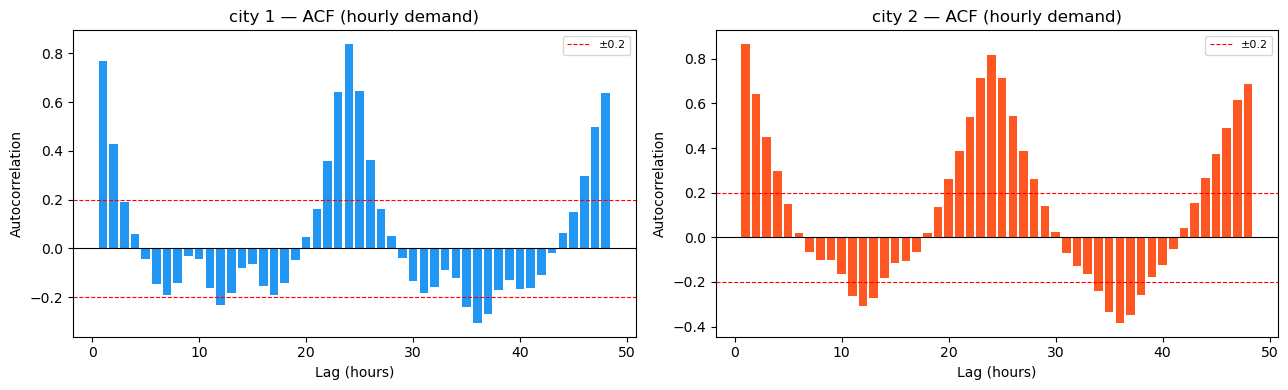

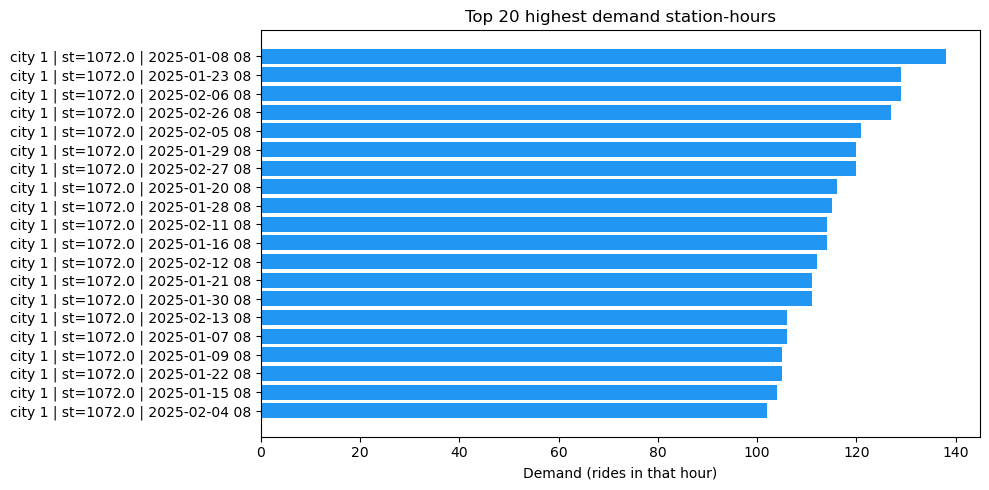

In [14]:
station_demand = (
    df.groupby(["city","start_station_id","hour_ts"]).size()
    .reset_index(name="demand")
    .groupby(["city","start_station_id"])["demand"]
    .agg(mean="mean", std="std", max="max").reset_index()
)

# Station variability scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, city in zip(axes, ["city 1","city 2"]):
    g = station_demand[station_demand["city"]==city]
    ax.scatter(g["mean"], g["std"], alpha=0.5, s=10, color=CITY_COLORS[city])
    ax.set_xlabel("Mean demand per station-hour"); ax.set_ylabel("Std of demand")
    ax.set_title(f"{city} — station variability (mean vs std)")
plt.tight_layout(); plt.show()

# ACF
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, city in zip(axes, ["city 1","city 2"]):
    g = df[df["city"]==city].copy()
    g["hour_ts_dt"] = pd.to_datetime(g["hour_ts"])
    city_hourly = g.groupby("hour_ts_dt").size().sort_index()
    lags = range(1, 49)
    acf_vals = [city_hourly.autocorr(lag=l) for l in lags]
    ax.bar(list(lags), acf_vals, color=CITY_COLORS[city], width=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axhline(0.2, color="red", linestyle="--", linewidth=0.8, label="±0.2")
    ax.axhline(-0.2, color="red", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Lag (hours)"); ax.set_ylabel("Autocorrelation")
    ax.set_title(f"{city} — ACF (hourly demand)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Top outlier station-hours
station_hour_demand = (
    df.groupby(["city","start_station_id","hour_ts"]).size()
    .reset_index(name="demand").sort_values("demand", ascending=False)
)
top20 = station_hour_demand.head(20)
fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{row.city} | st={row.start_station_id} | {str(row.hour_ts)[:13]}" for row in top20.itertuples()]
colors = [CITY_COLORS.get(row.city, "#999") for row in top20.itertuples()]
ax.barh(labels[::-1], top20["demand"].values[::-1], color=colors[::-1])
ax.set_xlabel("Demand (rides in that hour)")
ax.set_title("Top 20 highest demand station-hours")
plt.tight_layout(); plt.show()